In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/WorldBank_IND_Dataset.xls', sheet_name='Data', skiprows=3)
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,India,IND,"Intentional homicides, female (per 100,000 fem...",VC.IHR.PSRC.FE.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,2.750490e+00,2.723206e+00,2.645258e+00,2.594822e+00,2.452781e+00,2.486172e+00,2.374124e+00,NaN,NaN,NaN
1,India,IND,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,1.390981e+01,1.481815e+01,1.398202e+01,1.434676e+01,6.437810e+00,3.606469e+00,6.920047e+00,9.553904e+00,9.355812e+00,7.697773e+00
2,India,IND,Commercial service exports (current US$),TX.VAL.SERV.CD.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,1.612342e+11,1.846728e+11,2.043225e+11,2.141280e+11,2.024924e+11,2.398537e+11,3.086729e+11,3.369156e+11,3.742786e+11,4.116482e+11
3,India,IND,Merchandise exports by the reporting economy (...,TX.VAL.MRCH.WL.CD,1.199600e+09,1.248100e+09,1.226400e+09,1.372800e+09,1.421700e+09,1.344700e+09,...,2.595049e+11,2.940912e+11,3.206703e+11,3.223126e+11,2.750822e+11,3.935607e+11,4.503206e+11,4.290903e+11,NaN,NaN
4,India,IND,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R4.ZS,4.368123e+00,4.374649e+00,4.615134e+00,4.334207e+00,4.466484e+00,6.499591e+00,...,3.320138e+00,3.220998e+00,3.693345e+00,4.111875e+00,3.393921e+00,2.876813e+00,3.345394e+00,3.629428e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,India,IND,"Net ODA provided, to the least developed count...",DC.ODA.TLDC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1506,India,IND,"Net bilateral aid flows from DAC donors, Slove...",DC.DAC.SVNL.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.870000e+02,5.280000e+02,1.700000e+02,NaN,NaN,1.026490e+05,1.142860e+05,1.272600e+04,NaN,NaN
1507,India,IND,"Net bilateral aid flows from DAC donors, New Z...",DC.DAC.NZLL.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.800000e+05,2.100000e+05,1.831610e+05,1.430770e+05,1.250210e+05,9.402050e+05,4.288400e+04,NaN,NaN,NaN
1508,India,IND,"Net bilateral aid flows from DAC donors, Lithu...",DC.DAC.LTUL.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,9.220000e+03,6.461500e+04,2.559200e+04,1.199440e+05,9.176000e+04,1.765910e+05,1.637500e+05,7.156900e+04,NaN,NaN


### Setting the values upto 2 decimal places

**Reasoning:**

 Using pd.set_option() only changes how the values are displayed, not the actual data. This improves readability while preserving the original precision of the dataset for further analysis.


In [ ]:
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
# Summary of the dataset's structure
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1510 non-null   object 
 1   Country Code    1510 non-null   object 
 2   Indicator Name  1510 non-null   object 
 3   Indicator Code  1510 non-null   object 
 4   1960            265 non-null    float64
 5   1961            309 non-null    float64
 6   1962            315 non-null    float64
 7   1963            322 non-null    float64
 8   1964            326 non-null    float64
 9   1965            329 non-null    float64
 10  1966            325 non-null    float64
 11  1967            328 non-null    float64
 12  1968            331 non-null    float64
 13  1969            335 non-null    float64
 14  1970            432 non-null    float64
 15  1971            503 non-null    float64
 16  1972            462 non-null    float64
 17  1973            473 non-null    f

### Checking the null values in the dataset

The dataset contains a significant number of missing NaN values. However, this does not necessarily mean that the data is of poor quality. The missing values could simply indicate that the data was not recorded, reported, or made available for a particular year.

Replacing these missing values is not the best approach for this dataset, as it could distort the actual trends and lead to misleading inferences. Therefore, the missing values will be retained, and indicators with sufficient data coverage will be selected for further analysis.

In [ ]:
df.isnull().sum()

,0
Country Name,0
Country Code,0
Indicator Name,0
Indicator Code,0
1960,1245
...,...
2021,489
2022,488
2023,621
2024,794


In [ ]:
df.shape

(1510, 70)

In [ ]:
df.head(20) # First 20 rows

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,India,IND,"Intentional homicides, female (per 100,000 fem...",VC.IHR.PSRC.FE.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,2.75,2.72,2.65,2.59,2.45,2.49,2.37,NaN,NaN,NaN
1,India,IND,Travel services (% of commercial service exports),TX.VAL.TRVL.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,13.91,14.82,13.98,14.35,6.44,3.61,6.92,9.55,9.36,7.70
2,India,IND,Commercial service exports (current US$),TX.VAL.SERV.CD.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,161234203967.05,184672831370.24,204322540308.14,214127968224.74,202492396705.06,239853747442.25,308672880014.03,336915609399.43,374278618003.41,411648201449.55
3,India,IND,Merchandise exports by the reporting economy (...,TX.VAL.MRCH.WL.CD,1199600000.00,1248100000.00,1226400000.00,1372800000.00,1421700000.00,1344700000.00,...,259504855184.00,294091160000.00,320670270000.00,322312560000.00,275082219519.00,393560716448.00,450320580519.00,429090304638.00,NaN,NaN
4,India,IND,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R4.ZS,4.37,4.37,4.62,4.33,4.47,6.50,...,3.32,3.22,3.69,4.11,3.39,2.88,3.35,3.63,NaN,NaN
5,India,IND,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.OR.ZS,16.12,16.34,15.96,13.28,13.43,14.75,...,26.96,28.10,29.19,30.17,31.81,30.88,30.46,29.49,NaN,NaN
6,India,IND,Ores and metals exports (% of merchandise expo...,TX.VAL.MMTL.ZS.UN,NaN,NaN,6.76,7.90,8.73,8.94,...,3.16,4.01,3.53,3.54,4.70,4.83,3.73,3.89,3.69,NaN
7,India,IND,Fuel exports (% of merchandise exports),TX.VAL.FUEL.ZS.UN,NaN,NaN,0.98,1.02,1.35,1.19,...,10.64,12.19,15.07,13.78,10.03,14.28,21.75,20.71,17.09,NaN
8,India,IND,Export volume index (2015 = 100),TX.QTY.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,102.00,110.30,115.70,119.20,105.70,129.20,130.20,133.50,138.10,NaN
9,India,IND,Transport services (% of commercial service im...,TM.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,14.81,15.05,16.28,18.51,17.29,22.23,24.75,16.65,17.64,16.88


In [ ]:
# Checking for the missing values in the dataset specifically for the numerical columns
year_cols = df.loc[:, '2014':'2025'].columns

missing_values = df[year_cols].isna().sum()

missing_values

,0
2014,486
2015,467
2016,459
2017,472
2018,450
2019,499
2020,463
2021,489
2022,488
2023,621


In [ ]:
missing_percentage = (
    missing_values / len(df[year_cols]) * 100
)

pd.DataFrame({
    'missing_values': missing_values,
    'missing_percentage': missing_percentage
})

,missing_values,missing_percentage
2014,486,32.19
2015,467,30.93
2016,459,30.40
2017,472,31.26
2018,450,29.80
2019,499,33.05
2020,463,30.66
2021,489,32.38
2022,488,32.32
2023,621,41.13


In [ ]:
main_df = df[['Indicator Name', *year_cols]]
main_df

,Indicator Name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"Intentional homicides, female (per 100,000 fem...",2.88,2.66,2.75,2.72,2.65,2.59,2.45,2.49,2.37,NaN,NaN,NaN
1,Travel services (% of commercial service exports),12.58,13.49,13.91,14.82,13.98,14.35,6.44,3.61,6.92,9.55,9.36,7.70
2,Commercial service exports (current US$),156614386265.66,155717122914.28,161234203967.05,184672831370.24,204322540308.14,214127968224.74,202492396705.06,239853747442.25,308672880014.03,336915609399.43,374278618003.41,411648201449.55
3,Merchandise exports by the reporting economy (...,314637392240.00,263890314300.00,259504855184.00,294091160000.00,320670270000.00,322312560000.00,275082219519.00,393560716448.00,450320580519.00,429090304638.00,NaN,NaN
4,Merchandise exports to low- and middle-income ...,4.45,3.71,3.32,3.22,3.69,4.11,3.39,2.88,3.35,3.63,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,"Net ODA provided, to the least developed count...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1506,"Net bilateral aid flows from DAC donors, Slove...",NaN,NaN,387.00,528.00,170.00,NaN,NaN,102649.00,114286.00,12726.00,NaN,NaN
1507,"Net bilateral aid flows from DAC donors, New Z...",209999.99,670000.02,880000.00,209999.99,183161.01,143077.00,125021.00,940204.98,42884.00,NaN,NaN,NaN
1508,"Net bilateral aid flows from DAC donors, Lithu...",NaN,21540.00,9220.00,64615.00,25592.00,119944.00,91760.00,176590.99,163749.99,71569.00,NaN,NaN


In [ ]:
# Creating groups for each of the indicators ioncluding the variations
categories = {
    "GDP": ["GDP", "Gross domestic product"],
    "Inflation": ["Inflation", "Consumer price", "GDP deflator"],
    "Trade": ["Export", "Import"],
    "Employment": ["Employment", "Unemployment", "Labor force"],
    "Investment": ["Foreign direct investment", "Gross capital formation", "Investment"],
    "Human Capital Investment": ["Human Capital", "Investment on human capital"]
}

In [ ]:
# Looping through those groups
from ast import pattern
indicator_groups = {}

for category, data in categories.items():
    pattern = r'|'.join(data)

    indicator_groups[category] = main_df[
        main_df["Indicator Name"].str.contains(
            pattern,
            case=False,
            na=False
        )
    ]


### Univariate Time Series Analysis of GCF (% of GDP)

In [ ]:
with pd.option_context('display.max_colwidth', None):
  display(indicator_groups['Investment']['Indicator Name'])

,Indicator Name
128,Gross capital formation (% of GDP)
175,"Portfolio investment, bonds (PPG + PNG) (NFL, current US$)"
327,Public private partnerships investment in ICT (current US$)
328,Investment in ICT with private participation (current US$)
388,"Foreign direct investment, net outflows (% of GDP)"
490,Gross capital formation (current LCU)
522,Public private partnerships investment in transport (current US$)
523,Investment in transport with private participation (current US$)
569,Net ODA received (% of gross capital formation)
582,"Foreign direct investment, net inflows (BoP, current US$)"


In [ ]:
indicator_groups['Investment'].shape # Checking the dimension of the data

(25, 13)

In [ ]:
indicator_groups['Investment'].isnull().sum() # Checking null values for the years

,0
Indicator Name,0
2014,4
2015,3
2016,5
2017,3
2018,3
2019,7
2020,7
2021,5
2022,2


In [ ]:
# Checking how many missing years does each indicator have
investment = indicator_groups["Investment"].copy()

investment["Missing Years"] = investment.loc[:, "2014":"2025"].isna().sum(axis=1)

with pd.option_context("display.max_colwidth", None):
    display(investment[["Indicator Name", "Missing Years"]].sort_values("Missing Years"))


,Indicator Name,Missing Years
128,Gross capital formation (% of GDP),0
388,"Foreign direct investment, net outflows (% of GDP)",0
490,Gross capital formation (current LCU),0
582,"Foreign direct investment, net inflows (BoP, current US$)",0
776,"Portfolio investment, net (BoP, current US$)",0
779,"Foreign direct investment, net outflows (BoP, current US$)",0
711,Gross capital formation (constant 2015 US$),0
945,"Foreign direct investment, net (BoP, current US$)",0
1258,Gross capital formation (constant LCU),0
1259,Gross capital formation (current US$),0


In [ ]:
# Dropped the missing year column
investment.drop(columns="Missing Years", inplace=True)

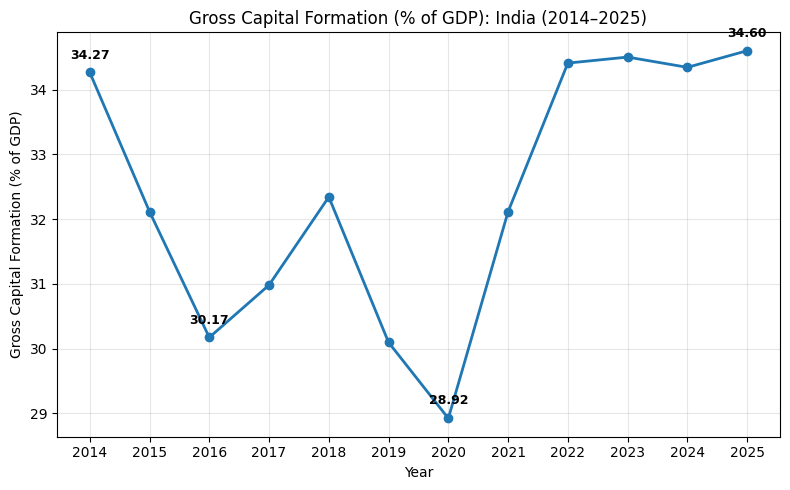

In [ ]:
gcf_gdp = investment[
    investment["Indicator Name"] == "Gross capital formation (% of GDP)"
]

x = [int(year) for year in year_cols]
y = gcf_gdp.loc[:, year_cols].iloc[0].astype(float)

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker="o", linewidth=2)

# Annotate key turning points
key_years = [2014, 2016, 2020, 2025]

for year in key_years:
    idx = x.index(year)
    plt.annotate(
        f"{y.iloc[idx]:.2f}",
        (x[idx], y.iloc[idx]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Gross Capital Formation (% of GDP): India (2014–2025)")
plt.xlabel("Year")
plt.ylabel("Gross Capital Formation (% of GDP)")
plt.xticks(x)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Key Data Points:**

- 2014 (34.27%) – Highest investment level at the beginning of the analysis period, serving as the baseline for comparison.
- 2016 (30.17%) – Marks the first trough, reflecting a slowdown in capital formation and private investment.
- 2020 (28.92%) – Lowest value during the study period, largely due to the economic disruption caused by the COVID-19 pandemic.
- 2025 (34.60%) – Latest available value, indicating that Gross Capital Formation recovered to and slightly exceeded its 2014 level.

**Key Takeways:**

- Based on what we can see - the period of 2014-2025 saw a W-shaped recovery.
- The post-2021 trend suggests a sustained recovery in investment activity and capital formation.

### Conclusion:

- Gross Capital Formation (% of GDP) declined during 2014–2016, indicating a slowdown in investment activity.
The indicator recovered in 2017–2018 before experiencing another sharp decline in 2020.
- A strong recovery is observed from 2021 onwards, with investment levels returning to pre-pandemic levels.
- Gross Capital Formation remained relatively stable between 2022 and 2025, suggesting sustained investment activity.
- Overall, the trend exhibits a W-shaped recovery, highlighting two distinct periods of decline followed by recovery.

### Univariate Time Series Analysis on FDI, net inflows (% of GDP)

In [ ]:
fdi_gdp = investment[
    investment['Indicator Name'] == 'Foreign direct investment, net inflows (% of GDP)'
        ].copy()
fdi_gdp

,Indicator Name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
940,"Foreign direct investment, net inflows (% of GDP)",1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99


In [ ]:
fdi_gdp[year_cols].isnull().sum() # No missing values found

,0
2014,0
2015,0
2016,0
2017,0
2018,0
2019,0
2020,0
2021,0
2022,0
2023,0


In [ ]:
fdi_gdp.describe() # the summary

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
mean,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99
25%,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99
50%,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99
75%,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99
max,1.70,2.09,1.94,1.51,1.56,1.78,2.41,1.41,1.54,0.80,0.72,0.99


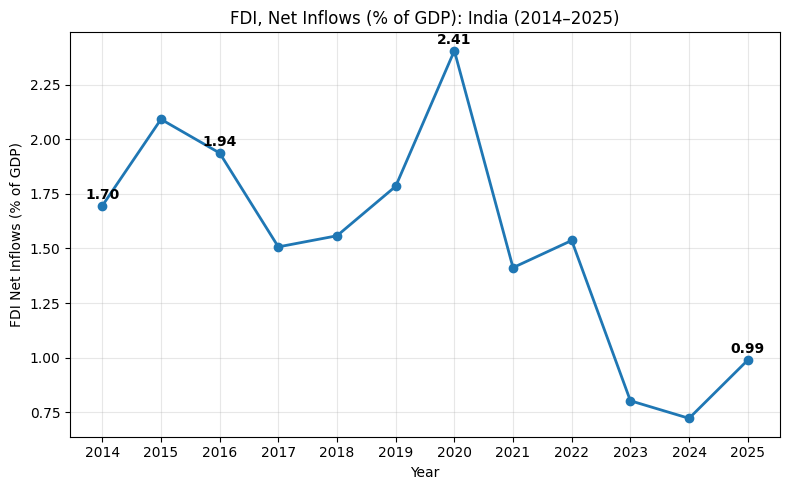

In [ ]:
x = [int(year) for year in year_cols]
y = fdi_gdp.loc[:, year_cols].iloc[0].astype(float)

plt.figure(figsize=(8,5))
plt.plot(x, y, marker='o', linewidth=2)

key_years = [2014, 2016, 2020, 2025]

for year in key_years:
    idx = x.index(year)
    plt.annotate(
        f"{y.iloc[idx]:.2f}",
        (x[idx], y.iloc[idx]),
        xytext=(0,5),
        textcoords="offset points",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("FDI, Net Inflows (% of GDP): India (2014–2025)")
plt.xlabel("Year")
plt.ylabel("FDI Net Inflows (% of GDP)")
plt.xticks(x)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion:

- FDI net inflows declined between 2015 and 2017, indicating weaker foreign investment during this period.
- A U-shaped recovery is observed between 2017 and 2020, with FDI inflows reaching their highest level in 2020.
- After 2020, FDI inflows declined sharply and reached trheir lowest level in 2024.
- A modest recovery is observed in 2025, although FDI inflows remain below the 2020 peak.
- Compared to GCF, FDI inflows show greater year-to-year volatility, suggesting that foreign investment is more sensitive to changing economic conditions.

### Comparative Trend Analysis - FDA (net inflows) & GCF

In [ ]:
gcf = investment[investment['Indicator Name'] == 'Gross capital formation (% of GDP)']
fdi = investment[investment['Indicator Name'] == 'Foreign direct investment, net inflows (% of GDP)']

# Extracting the yearly values
gcf_y = gcf.loc[:, year_cols].iloc[0].astype(float)
fdi_y = fdi.loc[:, year_cols].iloc[0].astype(float)

In [ ]:
compare_df = pd.DataFrame({
    "GCF": gcf_y.values,
    "FDI": fdi_y.values
})

compare_df.corr()

,GCF,FDI
GCF,1.00,-0.76
FDI,-0.76,1.00


Applying Corelation Coefficient to find out the relationship between the GCF and the FDI net inflows

### Interpretation:

- Close to +1 → Strong positive relationship
- Close to 0 → Weak or no linear relationship
- Close to -1 → Strong negative relationship

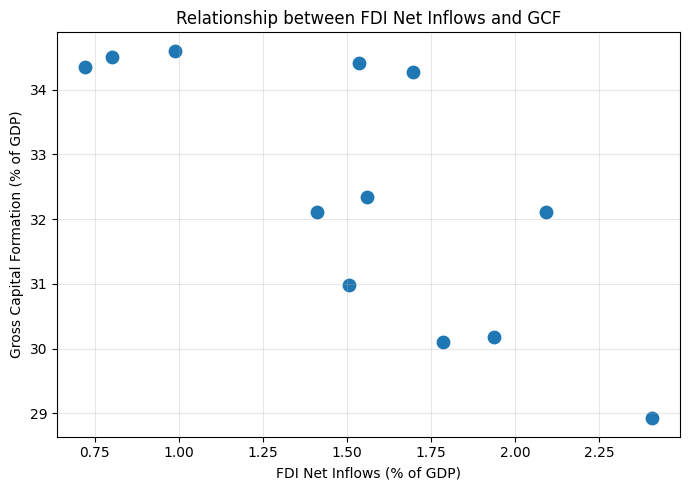

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    compare_df["FDI"],
    compare_df["GCF"],
    s=80
)

plt.title("Relationship between FDI Net Inflows and GCF")
plt.xlabel("FDI Net Inflows (% of GDP)")
plt.ylabel("Gross Capital Formation (% of GDP)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

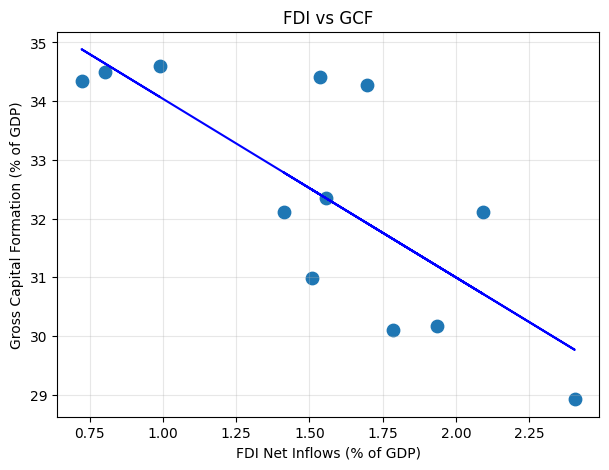

In [ ]:
# Adding a regression line which will helpo reveal the overall trend
m, b = np.polyfit(
    compare_df["FDI"],
    compare_df["GCF"],
    1
)

plt.figure(figsize=(7,5))

plt.scatter(
    compare_df["FDI"],
    compare_df["GCF"],
    s=80
)

plt.plot(
    compare_df["FDI"],
    m * compare_df["FDI"] + b,
    color="blue"
)

plt.title("FDI vs GCF")
plt.xlabel("FDI Net Inflows (% of GDP)")
plt.ylabel("Gross Capital Formation (% of GDP)")

plt.grid(alpha=0.3)
plt.show()

### Conclusion:

- The scatter plot indicates a weak negative relationship between FDI Net Inflows and Gross Capital Formation.
- The downward sloping regression line suggests that higher FDI inflows do not necessarily coincide with higher Gross Capital Formation.
- The wide spread of the data points indicates that the relationship is weak.
- This suggests that FDI alone is not sufficient to explain changes in Gross Capital Formation, and other domestic economic factors also influence investment activity.